<div style=
"background:linear-gradient(to left,yellow,blue,orange,green);
padding:10px;
text-align:center;
align-items:center;
border-radius:30px
"
>
<h3 style="color:linear-gradient(to bottom red,yellow,green);font-weight:40px;font-size:30px"><b>Dynamic Ride Price Predictions : UBER | RAPIDO </b></h3>
</div>

In [2]:
![Bike Image](./static/images/bike.jpeg)

'[Bike' is not recognized as an internal or external command,
operable program or batch file.


![Bike Image](./static/images/bike.jpeg)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

sns.set_theme(style='whitegrid',palette='muted')
plt.rcParams['figure.figsize'] = (10,7)
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['figure.labelsize'] = 10

`Regression Evaluation Metrics`

In [2]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [3]:
df = pd.read_csv('dynamic_pricing.csv')

df.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


`Basic Data Understanding`

In [4]:
rows,cols = df.shape

print(f'Number of rows : {rows:,}')
print(f'Number fo Columns : {cols:,}')
print(f'Total Elements : {rows*cols:,}')

Number of rows : 1,000
Number fo Columns : 10
Total Elements : 10,000


In [5]:
columns = df.columns.tolist()

print('COlumns in Data : \n',columns)

COlumns in Data : 
 ['Number_of_Riders', 'Number_of_Drivers', 'Location_Category', 'Customer_Loyalty_Status', 'Number_of_Past_Rides', 'Average_Ratings', 'Time_of_Booking', 'Vehicle_Type', 'Expected_Ride_Duration', 'Historical_Cost_of_Ride']


In [6]:
print(f'Data Types in Data : ')
df.dtypes

Data Types in Data : 


Number_of_Riders             int64
Number_of_Drivers            int64
Location_Category           object
Customer_Loyalty_Status     object
Number_of_Past_Rides         int64
Average_Ratings            float64
Time_of_Booking             object
Vehicle_Type                object
Expected_Ride_Duration       int64
Historical_Cost_of_Ride    float64
dtype: object

In [7]:
print('Memory usage in MB by Each column : \n')

df.memory_usage(deep=True)/1024

Memory usage in MB by Each column : 



Index                       0.128906
Number_of_Riders            7.812500
Number_of_Drivers           7.812500
Location_Category          53.677734
Customer_Loyalty_Status    53.412109
Number_of_Past_Rides        7.812500
Average_Ratings             7.812500
Time_of_Booking            54.630859
Vehicle_Type               54.687500
Expected_Ride_Duration      7.812500
Historical_Cost_of_Ride     7.812500
dtype: float64

In [8]:
print('Statistical summary of the Numerical Data : \n')
df.describe().T

Statistical summary of the Numerical Data : 



,count,mean,std,min,25%,50%,75%,max
Number_of_Riders,1000.0,60.372000,23.701506,20.000000,40.000000,60.000000,81.000000,100.000000
Number_of_Drivers,1000.0,27.076000,19.068346,5.000000,11.000000,22.000000,38.000000,89.000000
Number_of_Past_Rides,1000.0,50.031000,29.313774,0.000000,25.000000,51.000000,75.000000,100.000000
Average_Ratings,1000.0,4.257220,0.435781,3.500000,3.870000,4.270000,4.632500,5.000000
Expected_Ride_Duration,1000.0,99.588000,49.165450,10.000000,59.750000,102.000000,143.000000,180.000000
Historical_Cost_of_Ride,1000.0,372.502623,187.158756,25.993449,221.365202,362.019426,510.497504,836.116419


In [9]:
print('Statistical summary of Categorical Data : \n')
df.describe(include='object').T

Statistical summary of Categorical Data : 



,count,unique,top,freq
Location_Category,1000,3,Urban,346
Customer_Loyalty_Status,1000,3,Silver,367
Time_of_Booking,1000,4,Night,276
Vehicle_Type,1000,2,Premium,522


In [10]:
print('Missing values in a data in Each Column : ')
df.isnull().sum()

Missing values in a data in Each Column : 


Number_of_Riders           0
Number_of_Drivers          0
Location_Category          0
Customer_Loyalty_Status    0
Number_of_Past_Rides       0
Average_Ratings            0
Time_of_Booking            0
Vehicle_Type               0
Expected_Ride_Duration     0
Historical_Cost_of_Ride    0
dtype: int64

In [11]:
print('Duplicate rows in a Data : ')
df[df.duplicated()]

Duplicate rows in a Data : 


,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride


In [12]:
print('General Information about the Data : \n')
df.info()

General Information about the Data : 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   object 
 3   Customer_Loyalty_Status  1000 non-null   object 
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   object 
 7   Vehicle_Type             1000 non-null   object 
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 78.3+ KB


`Data Validation`

In [13]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

print('Numerical Columns : \n',numerical_columns)
print('\nCategorical Columns : \n',categorical_columns)

Numerical Columns : 
 ['Number_of_Riders', 'Number_of_Drivers', 'Number_of_Past_Rides', 'Average_Ratings', 'Expected_Ride_Duration', 'Historical_Cost_of_Ride']

Categorical Columns : 
 ['Location_Category', 'Customer_Loyalty_Status', 'Time_of_Booking', 'Vehicle_Type']


In [14]:
print('Identifing Invalid Range in Numerical Columns : \n')

for col in numerical_columns:
  print(f'{col} : [{df[col].min()}    ->   {df[col].max()}]\n')


Identifing Invalid Range in Numerical Columns : 

Number_of_Riders : [20    ->   100]

Number_of_Drivers : [5    ->   89]

Number_of_Past_Rides : [0    ->   100]

Average_Ratings : [3.5    ->   5.0]

Expected_Ride_Duration : [10    ->   180]

Historical_Cost_of_Ride : [25.993449448411635    ->   836.1164185613576]



In [15]:
print('Indentifying Invalid Range in Categorical Columns : \n')

for col in categorical_columns:
  print(f'{col} : \n{df[col].unique().tolist()}\n')

Indentifying Invalid Range in Categorical Columns : 

Location_Category : 
['Urban', 'Suburban', 'Rural']

Customer_Loyalty_Status : 
['Silver', 'Regular', 'Gold']

Time_of_Booking : 
['Night', 'Evening', 'Afternoon', 'Morning']

Vehicle_Type : 
['Premium', 'Economy']



In [16]:
print('Checking wrong Data types : \n')

for col in columns:
  print(f'{col} : Dtype : [{df[col].dtype}]  Length : {df[col].nunique()}')

Checking wrong Data types : 

Number_of_Riders : Dtype : [int64]  Length : 81
Number_of_Drivers : Dtype : [int64]  Length : 79
Location_Category : Dtype : [object]  Length : 3
Customer_Loyalty_Status : Dtype : [object]  Length : 3
Number_of_Past_Rides : Dtype : [int64]  Length : 101
Average_Ratings : Dtype : [float64]  Length : 151
Time_of_Booking : Dtype : [object]  Length : 4
Vehicle_Type : Dtype : [object]  Length : 2
Expected_Ride_Duration : Dtype : [int64]  Length : 171
Historical_Cost_of_Ride : Dtype : [float64]  Length : 1000


`Exploratory Data Analysis`

Target variable Distribution : 



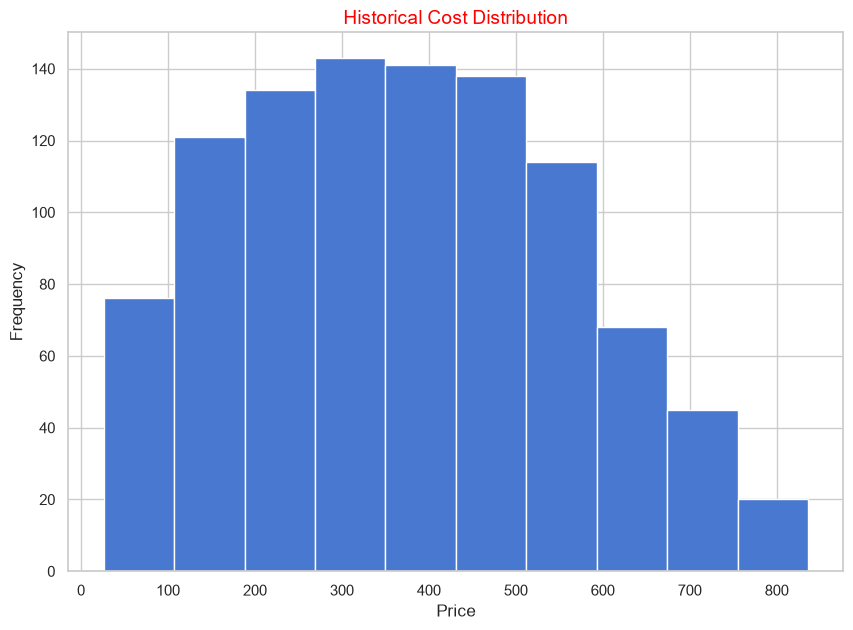

In [17]:
print('Target variable Distribution : \n')


df.Historical_Cost_of_Ride.plot(kind='hist')
plt.title('Historical Cost Distribution',fontsize=14,color='red')
plt.xlabel('Price')
plt.show()

Categorical Columns Distribution : 



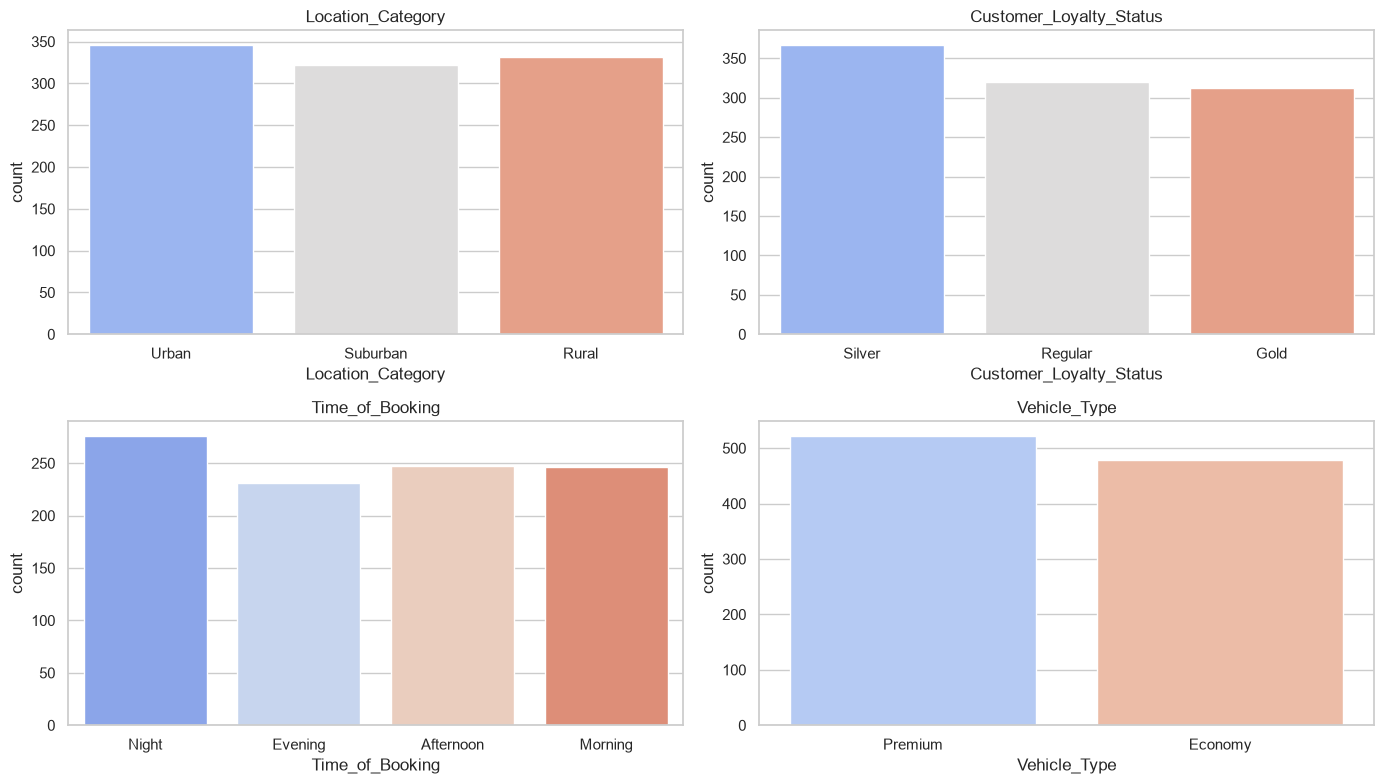

In [18]:
print('Categorical Columns Distribution : \n')

fig,ax = plt.subplots(2,2,figsize=(14,8))
ax = ax.flatten()

for i,col in enumerate(categorical_columns):
  sns.countplot(x=df[col],ax=ax[i],palette='coolwarm')
  ax[i].set_title(col)


plt.tight_layout()
plt.show()
  


Numerical Column Distribution : 



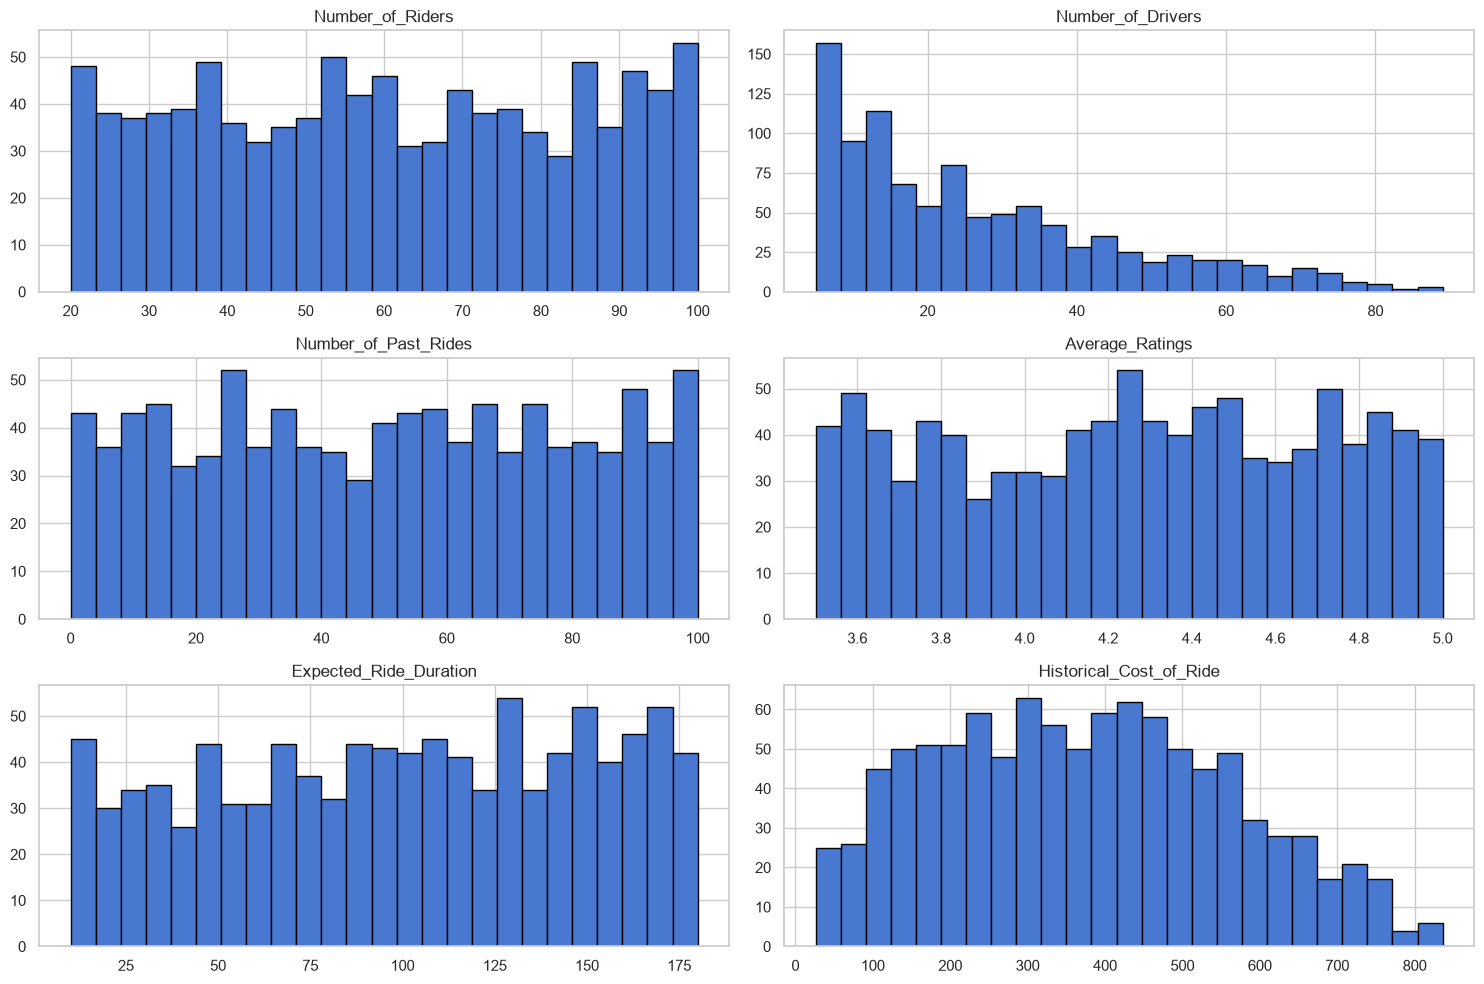

In [19]:
print('Numerical Column Distribution : \n')

df[numerical_columns].hist(figsize=(15,10),bins=25,edgecolor='black')
plt.tight_layout()
plt.show()

Relationship between Expected Ride Duration and Price


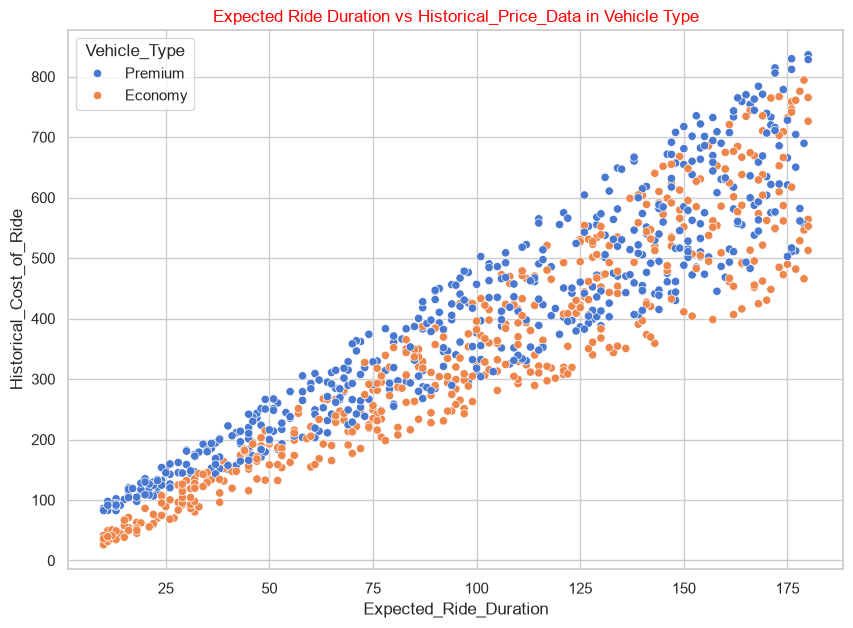

Note : 
The Person who Booked Premium Rider has high Cost compared to who booked Economy Driver.


In [20]:
print('Relationship between Expected Ride Duration and Price')

sns.scatterplot(x='Expected_Ride_Duration',y='Historical_Cost_of_Ride',data=df,hue='Vehicle_Type')
plt.title('Expected Ride Duration vs Historical_Price_Data in Vehicle Type',color='red')
plt.show()
print('Note : \nThe Person who Booked Premium Rider has high Cost compared to who booked Economy Driver.')

Relationship between Expected Ride Duration and Price in Location Category


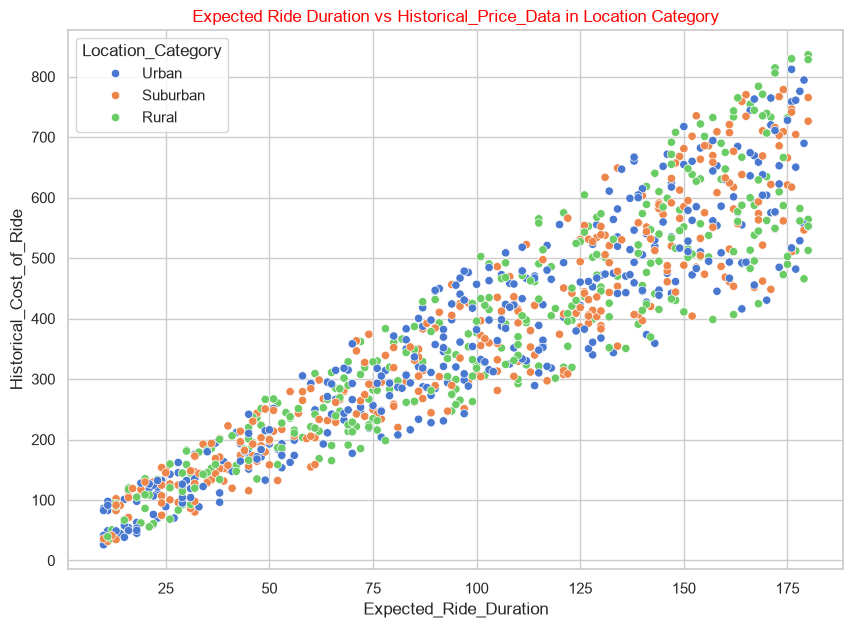

Note : 
 1.The Ride Prices is not Varying by Location Category.


In [21]:
print('Relationship between Expected Ride Duration and Price in Location Category')

sns.scatterplot(x='Expected_Ride_Duration',y='Historical_Cost_of_Ride',data=df,hue='Location_Category')
plt.title('Expected Ride Duration vs Historical_Price_Data in Location Category',color='red')
plt.show()

print('Note : \n 1.The Ride Prices is not Varying by Location Category.')

Customer Loyalty Status in Location Category



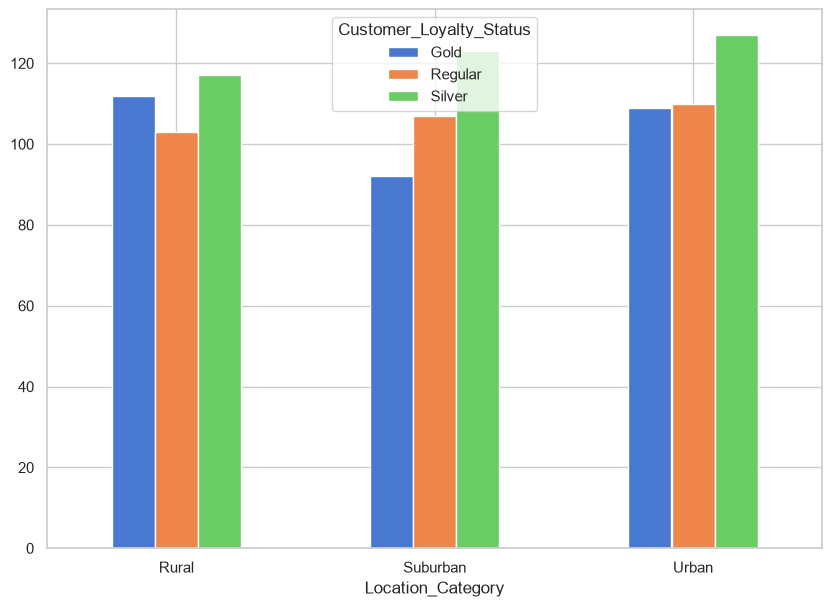

In [22]:
print('Customer Loyalty Status in Location Category\n')

tab = pd.crosstab(df['Location_Category'],df['Customer_Loyalty_Status'])

tab.plot(kind='bar')

plt.xticks(rotation=0)

plt.show()

Number of Riders Available at the Time of Bookings. 


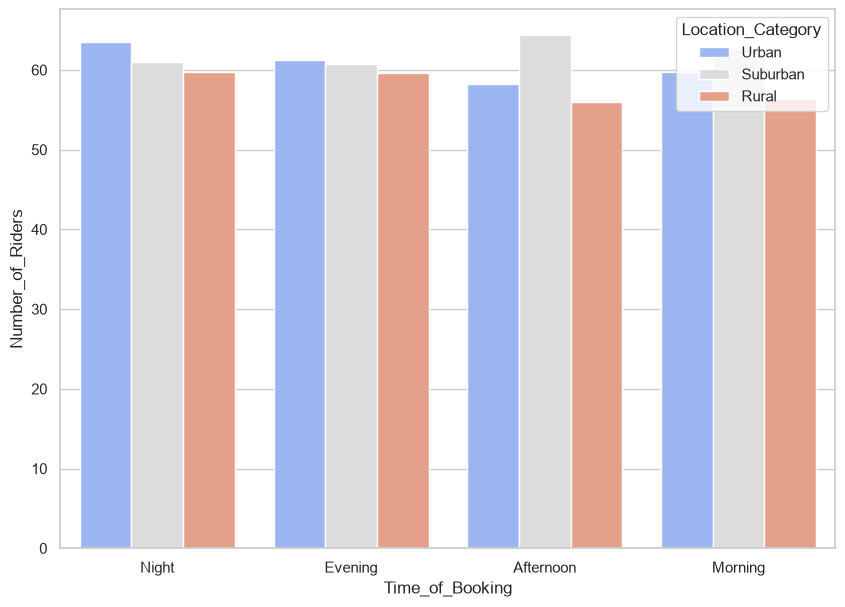

In [23]:
print('Number of Riders Available at the Time of Bookings. ')

sns.barplot(x='Time_of_Booking',y='Number_of_Riders',data=df,errorbar=None,palette='coolwarm',hue='Location_Category')
plt.show()

`Outlier Handling`

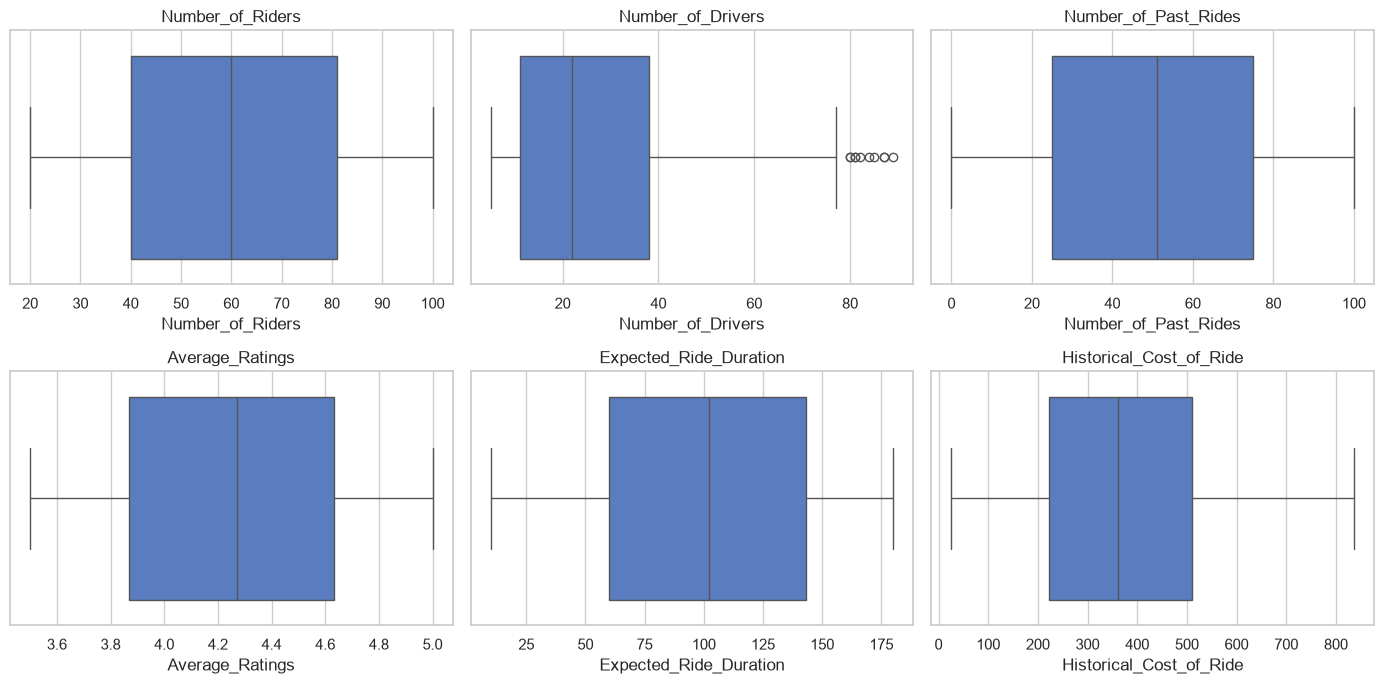

In [24]:
fig,ax = plt.subplots(2,3,figsize=(14,7))

ax = ax.flatten()

for i,col in enumerate(numerical_columns):
  sns.boxplot(x=col,data=df,ax=ax[i])
  ax[i].set_title(col)

plt.tight_layout()
plt.show()
  

In [25]:
print('Identifying Outlier Percentage')

Q1 = df['Number_of_Drivers'].quantile(0.25)

Q3 = df['Number_of_Drivers'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

new_df = df[df.Number_of_Drivers >= upper_bound]

print('Outlier Percentage in Number of Drivers COlumns : ',(new_df.shape[0]/df.shape[0])*100,'%')

print('Remove the Outliers in Number of Drivers Column. Beacause it is No effect.')

df = df[df.Number_of_Drivers < upper_bound]

Identifying Outlier Percentage
Outlier Percentage in Number of Drivers COlumns :  1.0 %
Remove the Outliers in Number of Drivers Column. Beacause it is No effect.


`Train-Test-Split`

In [26]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(
  df.drop(columns=['Historical_Cost_of_Ride'],axis=1),
  df.Historical_Cost_of_Ride,
  test_size=0.2,
  random_state=42
)

In [27]:
# Removing the Target column in Numerical Column

numerical_columns = [col for col in numerical_columns if col != 'Historical_Cost_of_Ride']

numerical_columns

['Number_of_Riders',
 'Number_of_Drivers',
 'Number_of_Past_Rides',
 'Average_Ratings',
 'Expected_Ride_Duration']

`Feature Engineering`

In [28]:
print('Making the Preprocessor pipeline : ')

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_columns
        ),
        (
            'ohe',
            OneHotEncoder(handle_unknown='ignore',drop='first'),
            ['Location_Category', 'Time_of_Booking', 'Vehicle_Type']
        ),
        (
            'ord',
            OrdinalEncoder(categories=[['Regular', 'Silver', 'Gold']]),
            ['Customer_Loyalty_Status']
        )
    ]
)

preprocessor

Making the Preprocessor pipeline : 


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [29]:
print('Transformed the Data')

x_train_transformed = preprocessor.fit_transform(x_train)

x_test_transformed = preprocessor.transform(x_test)

x_train_transformed

Transformed the Data


array([[ 0.9282475 ,  1.83960533, -0.38129118, ...,  1.        ,
         1.        ,  0.        ],
       [ 0.20927354, -1.18314865, -0.89562514, ...,  1.        ,
         0.        ,  1.        ],
       [-0.12906715,  0.88799759, -0.48415797, ...,  0.        ,
         1.        ,  1.        ],
       ...,
       [-0.97491886, -0.90326403, -0.79275835, ...,  0.        ,
         0.        ,  2.        ],
       [-0.50970042,  0.66408989, -0.17555759, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.42073647,  1.16788222, -1.61569268, ...,  0.        ,
         1.        ,  1.        ]], shape=(792, 12))

In [30]:
print('Getting Feature names')
preprocessor_feature_names = preprocessor.get_feature_names_out()

preprocessor_feature_names

Getting Feature names


array(['num__Number_of_Riders', 'num__Number_of_Drivers',
       'num__Number_of_Past_Rides', 'num__Average_Ratings',
       'num__Expected_Ride_Duration', 'ohe__Location_Category_Suburban',
       'ohe__Location_Category_Urban', 'ohe__Time_of_Booking_Evening',
       'ohe__Time_of_Booking_Morning', 'ohe__Time_of_Booking_Night',
       'ohe__Vehicle_Type_Premium', 'ord__Customer_Loyalty_Status'],
      dtype=object)

`Detecting Non-linear Relationship`

In [31]:
"""
Mututal Information :
Mutual Information measures any dependency (linear or non-linear) between a feature and the target
"""

from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(x_train_transformed,y_train,random_state=42)

mi_scores = pd.Series(mi,index=preprocessor_feature_names).sort_values(ascending=False)

print(mi_scores)


print('\nNote :\nRide Duration is Linearly relationship with the Target Variable.')

num__Expected_Ride_Duration        1.161091
num__Number_of_Drivers             0.040552
ohe__Location_Category_Urban       0.035661
ohe__Vehicle_Type_Premium          0.034737
num__Number_of_Past_Rides          0.016459
num__Average_Ratings               0.011603
ord__Customer_Loyalty_Status       0.001504
num__Number_of_Riders              0.000000
ohe__Location_Category_Suburban    0.000000
ohe__Time_of_Booking_Evening       0.000000
ohe__Time_of_Booking_Morning       0.000000
ohe__Time_of_Booking_Night         0.000000
dtype: float64

Note :
Ride Duration is Linearly relationship with the Target Variable.


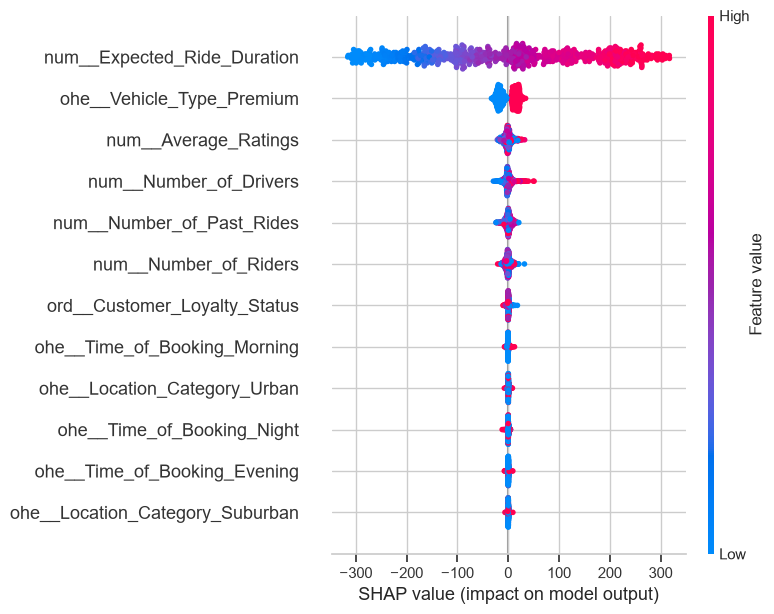

In [39]:
"""
SHAP VALUES: 1. Non-linear effects, 2. Feature Interactions, 3. Important variables.

"""


from sklearn.ensemble import RandomForestRegressor
import shap

rf = RandomForestRegressor(random_state=42)

# converting to dataframe
shapes_df = pd.DataFrame(x_train_transformed,columns=preprocessor_feature_names)
rf.fit(shapes_df,y_train)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(shapes_df)

shap.summary_plot(shap_values,shapes_df)

In [33]:
import numpy
import numba
import sklearn

print("NumPy :", numpy.__version__)
print("Numba:", numba.__version__)
print("Scikit-learn:", sklearn.__version__)

NumPy : 2.3.5
Numba: 0.65.1
Scikit-learn: 1.9.0


`Feature Selection`

Feature Selection based on Heat Map


<Axes: >

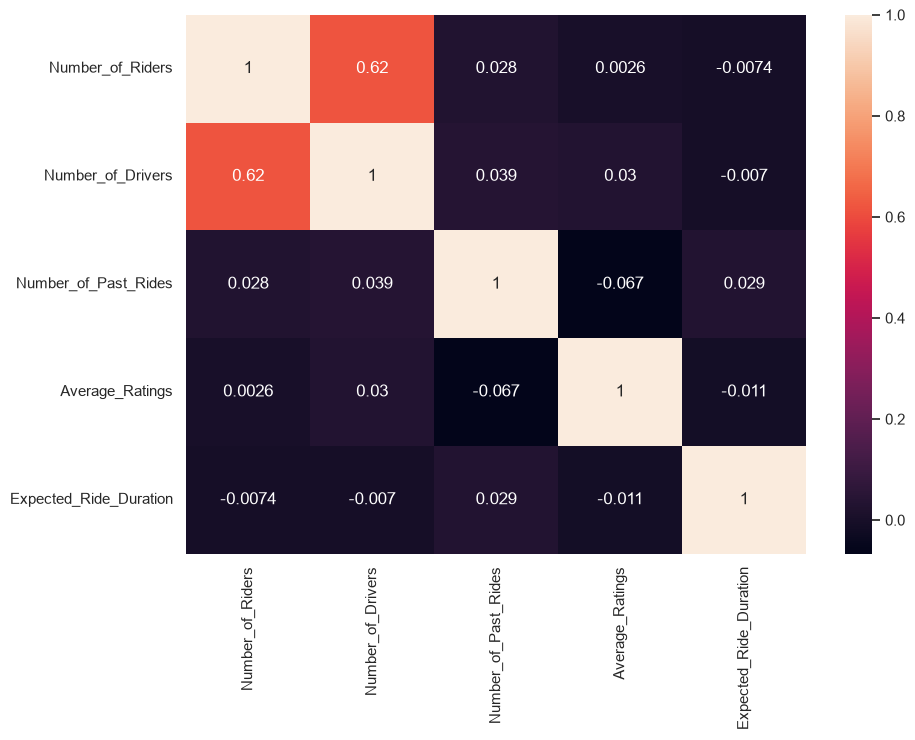

In [34]:
print('Feature Selection based on Heat Map')

sns.heatmap(df[numerical_columns].corr(),cbar=True,annot=True)

In [35]:
print('Remove Highly Correlation Pairs in a Target')

corr = df[numerical_columns[:-1]].corr()

correlated_pairs = {}

for row in range(corr.shape[0]):
  for col in range(row+1,corr.shape[0]):
    corr_value = corr.iloc[row,col]
    
    if corr_value > 0.60:
      column_1 = numerical_columns[row]
      column_2 = numerical_columns[col]
      correlated_pairs[column_1] = column_2
      

print(correlated_pairs)

Remove Highly Correlation Pairs in a Target
{'Number_of_Riders': 'Number_of_Drivers'}


`Feature Selection in Forward Selection`

In [36]:

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

print('Find the Best Features  based on Forward Selection')

# For Regression Problems. We use All types of Regression Algorithm.
model_linear = LinearRegression()

sfs = SequentialFeatureSelector(
  estimator=model_linear,
  n_features_to_select='auto',
  direction='forward',
  scoring='r2',
  cv=5,
  n_jobs=-1
)
sfs.fit(x_train_transformed,y_train)

# selected Features

selected_features = preprocessor_feature_names[sfs.get_support()]

print('Selected Features : \n',selected_features)

Find the Best Features  based on Forward Selection
Selected Features : 
 ['num__Number_of_Riders' 'num__Number_of_Drivers' 'num__Average_Ratings'
 'num__Expected_Ride_Duration' 'ohe__Time_of_Booking_Evening'
 'ohe__Vehicle_Type_Premium']


In [40]:
# selecting the best features from the DataFrames

train_df = pd.DataFrame(x_train_transformed,columns=preprocessor_feature_names)

test_df = pd.DataFrame(x_test_transformed,columns=preprocessor_feature_names)

# Training DataFrame

x_train_best_features = train_df[selected_features]

x_test_best_features = test_df[selected_features]

x_train_best_features.shape,x_test_best_features.shape

((792, 6), (198, 6))

`Model Building`

In [56]:
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [57]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "KNN": KNeighborsRegressor(),
    "Random Forest": RandomForestRegressor(),
    "XGBoost": XGBRegressor(),
    "Ridge":Ridge()
}

`Finding the Best Model`

In [58]:
def evaluation_metrics(y_true,y_pred):
  r2 = r2_score(y_true,y_pred)
  mae = mean_absolute_error(y_true,y_pred)
  mse = mean_squared_error(y_true,y_pred)
  
  return r2,mse,mae

In [59]:
for i,model in enumerate(list(models.values())):
  
  # Train the Mode
  model.fit(x_train_best_features,y_train)
  
  # training predictions
  y_train_pred = model.predict(x_train_best_features)
  r2_1,mse_1,mae_1 = evaluation_metrics(y_train,y_train_pred)
  
  # Testing predictions
  y_test_pred = model.predict(x_test_best_features)
  r2_2,mse_2,mae_2 = evaluation_metrics(y_test,y_test_pred)
  
  print(f'========== {list(models.keys())[i]} ========')
  print('Training Performance : ')
  print('Mean Squared Error : ',mse_1)
  print('Mean Absolute Error : ',mae_1)
  print('R2 Score : ',r2_1)
  print('Testing Performance  : ')
  print('Mean Squared Error : ',mse_2)
  print('Mean Absolute Error : ',mae_2)
  print('R2 Score : ',r2_2)
  print('\n')

========== Linear Regression ========
Training Performance : 
Mean Squared Error :  4280.909208982753
Mean Absolute Error :  51.15905458729215
R2 Score :  0.8758403271738349
Testing Performance  : 
Mean Squared Error :  4532.886660947776
Mean Absolute Error :  52.16471043662691
R2 Score :  0.8729248192368481


========== Decision Tree ========
Training Performance : 
Mean Squared Error :  0.0
Mean Absolute Error :  0.0
R2 Score :  1.0
Testing Performance  : 
Mean Squared Error :  10767.119714655993
Mean Absolute Error :  75.65051902029711
R2 Score :  0.6981540050788906


========== KNN ========
Training Performance : 
Mean Squared Error :  4192.147749229927
Mean Absolute Error :  50.455740469431056
R2 Score :  0.8784146853917945
Testing Performance  : 
Mean Squared Error :  6451.717534529005
Mean Absolute Error :  62.89882582377673
R2 Score :  0.8191322145783262


========== Random Forest ========
Training Performance : 
Mean Squared Error :  725.8506798381763
Mean Absolute Error :  20

Background dataset has 792 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=792 when initializing the masker.


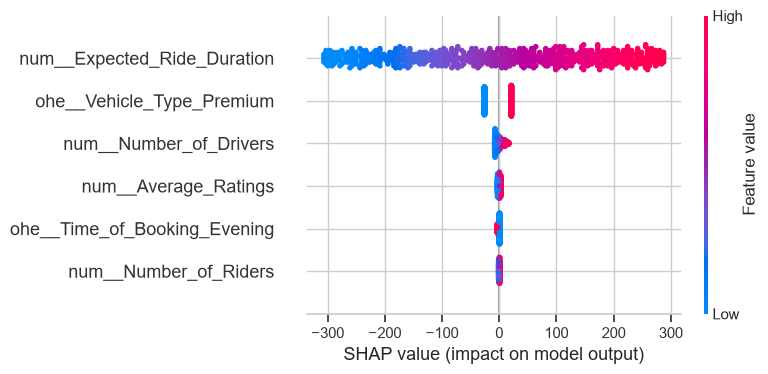

In [60]:
# Explaining how my Linear Model uses the Featues

import shap

linear_model = Ridge()

linear_model.fit(x_train_best_features, y_train)

explainer = shap.LinearExplainer(
    linear_model,
    x_train_best_features
)

shap_values = explainer.shap_values(x_train_best_features)

shap.summary_plot(
    shap_values,
    x_train_best_features
)

In [69]:
# Applying Logarithm Functions on the Target variable


ridge = Ridge()

ridge.fit(x_train_best_features,y_train)

# training predictions
y_train_pred = ridge.predict(x_train_best_features)
r2_1,mse_1,mae_1 = evaluation_metrics(y_train,y_train_pred)

# Testing predictions
y_test_pred = ridge.predict(x_test_best_features)
r2_2,mse_2,mae_2 = evaluation_metrics(y_test,y_test_pred)

print('Training Performance : ')
print('Mean Squared Error : ',mse_1)
print('Mean Absolute Error : ',mae_1)
print('R2 Score : ',r2_1)
print('Testing Performance  : ')
print('Mean Squared Error : ',mse_2)
print('Mean Absolute Error : ',mae_2)
print('R2 Score : ',r2_2)
print('\n')



Training Performance : 
Mean Squared Error :  4280.969647677117
Mean Absolute Error :  51.14898849929103
R2 Score :  0.8758385742638449
Testing Performance  : 
Mean Squared Error :  4535.294652695869
Mean Absolute Error :  52.17435584533667
R2 Score :  0.872857313470754




In [73]:
from sklearn.model_selection import cross_val_score

cv = cross_val_score(
  estimator=ridge,
  X=x_train_best_features,
  y=y_train,
  cv=5,
  scoring='r2')

print('Cross Validation Scores')
print(cv)

print('\n Mean R2 Score : ',cv.mean())
print('\n Standard Deviation : ',cv.std())

Cross Validation Scores
[0.86949294 0.8912723  0.87477879 0.86583558 0.86145852]

 Mean R2 Score :  0.8725676258839872

 Standard Deviation :  0.010324151607199223


`Error Analysis`

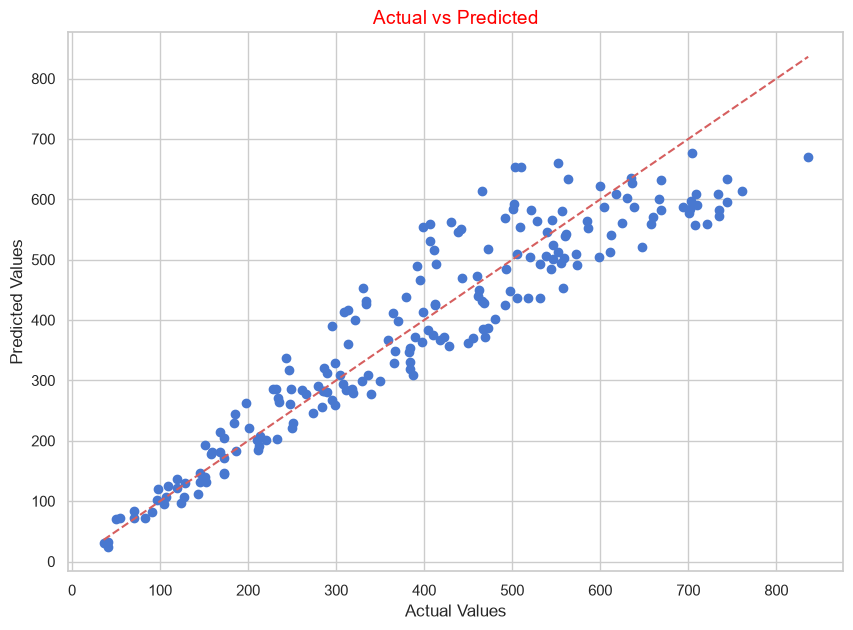

In [75]:
plt.scatter(y_test,y_test_pred)

plt.plot(
  [y_test.min(),y_test.max()],
  [y_test.min(),y_test.max()],
  'r--'
)

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted',color='red',fontsize=14)
plt.show()

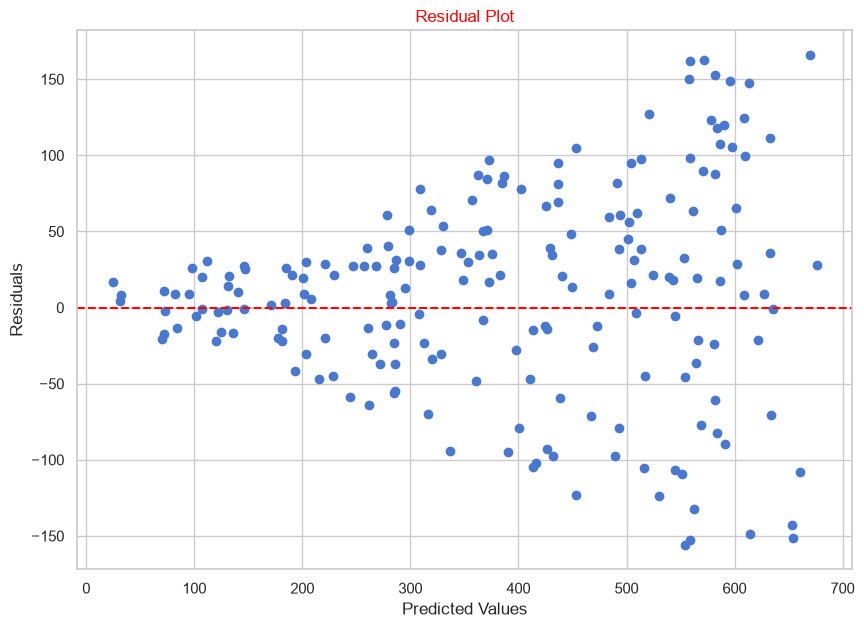

In [76]:
# Residual Plot

residual = y_test - y_test_pred

plt.scatter(y_test_pred,residual)

plt.axhline(y=0,color='red',linestyle='--')

plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.title('Residual Plot',color='red')

plt.show()

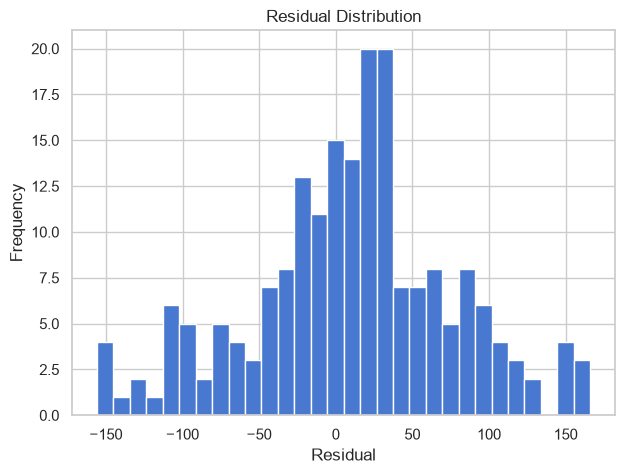

In [82]:
plt.figure(figsize=(7,5))

plt.hist(residual, bins=30)

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.title("Residual Distribution")

plt.show()

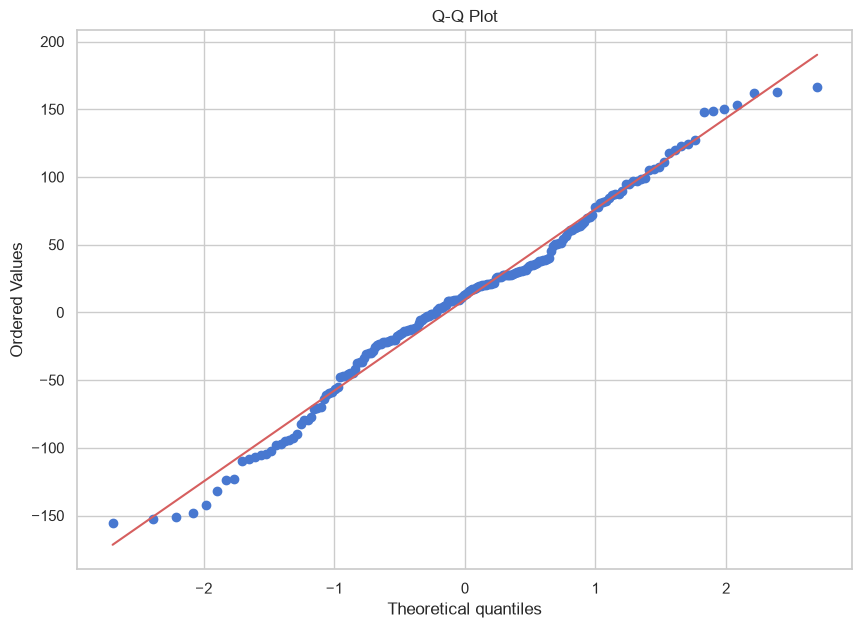

In [83]:
import scipy.stats as stats

stats.probplot(residual, dist="norm", plot=plt)

plt.title("Q-Q Plot")

plt.show()

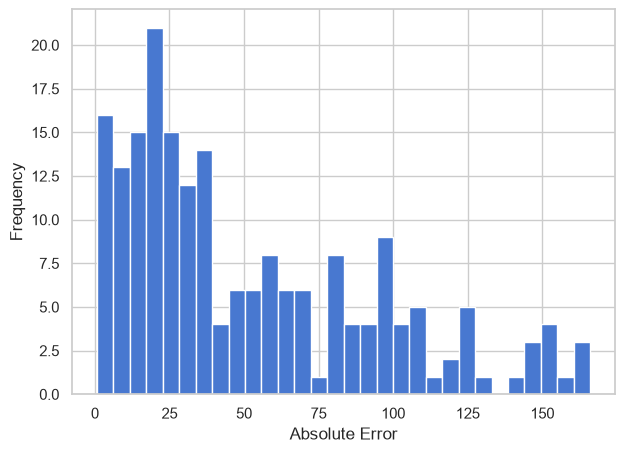

In [84]:
absolute_error = abs(y_test - y_test_pred)

plt.figure(figsize=(7,5))

plt.hist(absolute_error, bins=30)

plt.xlabel("Absolute Error")

plt.ylabel("Frequency")

plt.show()

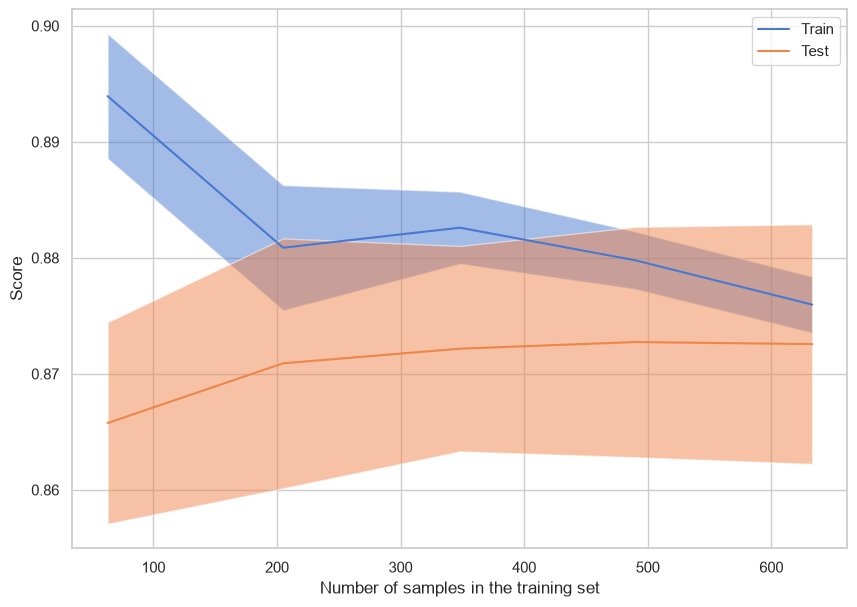

In [86]:
# To Show the Model is Overfitting or Underfitting based on the Model


from sklearn.model_selection import LearningCurveDisplay

LearningCurveDisplay.from_estimator(
    model,
    x_train_best_features,
    y_train,
    cv=5
)

plt.show()

In [87]:
selected_features

array(['num__Number_of_Riders', 'num__Number_of_Drivers',
       'num__Average_Ratings', 'num__Expected_Ride_Duration',
       'ohe__Time_of_Booking_Evening', 'ohe__Vehicle_Type_Premium'],
      dtype=object)

`Export Model and Preprocessor`

In [90]:
import pickle

with open('dynamic_price_preprocessor.pkl','wb') as file:
  pickle.dump(preprocessor,file)

In [91]:
with open('dynamic_price_model.pkl','wb') as file:
  pickle.dump(ridge,file)

In [93]:
x_train_best_features.head()

,num__Number_of_Riders,num__Number_of_Drivers,num__Average_Ratings,num__Expected_Ride_Duration,ohe__Time_of_Booking_Evening,ohe__Vehicle_Type_Premium
0,0.928247,1.839605,-1.729541,-0.650786,0.0,1.0
1,0.209274,-1.183149,-1.637183,0.409251,0.0,0.0
2,-0.129067,0.887998,-1.521734,1.387746,0.0,1.0
3,-1.567015,-1.015218,1.110492,0.368480,0.0,0.0
4,-0.848041,-0.343495,0.348532,-0.324621,0.0,0.0


In [94]:
x_train

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration
759,82,59,Rural,Regular,39,3.50,Night,Premium,67
218,65,5,Rural,Silver,24,3.54,Night,Economy,119
298,57,42,Rural,Silver,36,3.59,Afternoon,Premium,167
50,23,8,Urban,Silver,27,4.73,Afternoon,Economy,117
725,40,20,Rural,Regular,11,4.40,Afternoon,Economy,83
...,...,...,...,...,...,...,...,...,...
108,34,19,Rural,Regular,51,4.20,Night,Premium,166
273,92,14,Urban,Silver,57,3.73,Morning,Premium,133
868,37,10,Suburban,Gold,27,4.26,Afternoon,Economy,143
439,48,38,Urban,Silver,45,4.17,Afternoon,Economy,87
